32.3698733556867
7918381846959.889
Solution:
$\alpha_a = -0.7958304759642035
$\alpha_n = -1.2837166773952888
$\Delta_a = 1.1758622428089813
$\Delta_n = 0.2504199954898946
Relative error: 0.00031925005706230826


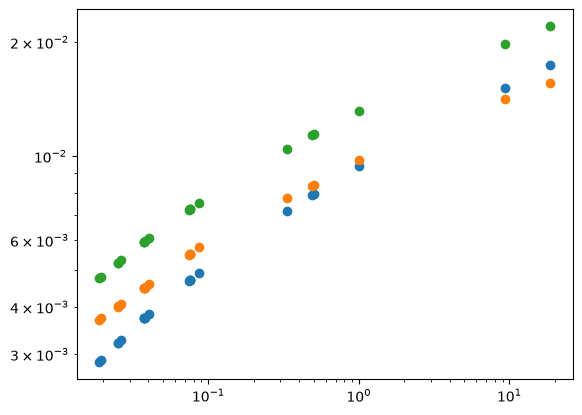

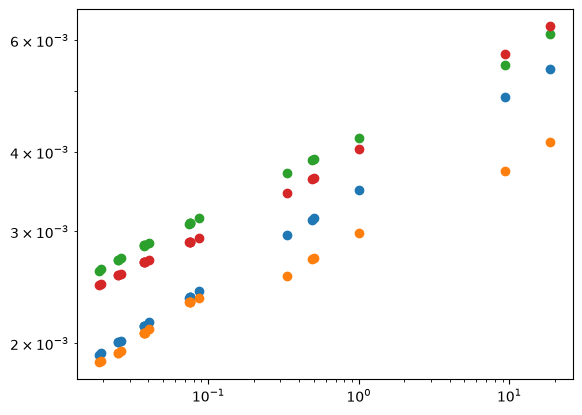

In [ ]:
from matplotlib.pyplot import scatter, xscale, show, yscale
from alna.tide_correction_model import tide_angular_frequencies_to_cycle_per_yr
from alna.rheological_formulas import find_tau_m_sup
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import least_squares
from alna.tide_correction_model import (
    SOLID_TIDE_CORRECTION_MODELS_DEFAULT_FILE_NAME,
    POLE_MODELS_PATH,
    load_base_model,
)
from numpy import array, log10, flip
from base_models import load_base_model
from numpy import array
from alna.tide_correction_model import REFERENCE_K2, IERS_LONG_PERIOD_ZONAL_TIDES
from alna.tide_correction_model import POLE_MODELS_PATH

k2_reference = array(
    [
        REFERENCE_K2 + delta_k2_r + 1j * k2_i
        for _, _, delta_k2_r, k2_i in IERS_LONG_PERIOD_ZONAL_TIDES
    ]
)
H_f = abs(
    array(
        [
            0.02793,  # 055.565
            -0.00027,  # 055.575
            -0.00492,  # 056.554 — Sa
            -0.03100,  # 057.555 — Ssa
            0.00077,  # 057.565
            -0.00181,  # 058.554
            -0.00673,  # 063.655 — Msm
            0.00231,  # 065.445
            -0.03518,  # 065.455 — Mm
            0.00229,  # 065.465
            0.00188,  # 065.655
            -0.00583,  # 073.555 — Msf
            -0.00288,  # 075.355
            -0.06663,  # 075.555 — Mf
            -0.02762,  # 075.565
            -0.00258,  # 075.575
            -0.00242,  # 083.655 — Mstm
            -0.01276,  # 085.455 — Mtm
            -0.00529,  # 085.465
            -0.00204,  # 093.555 — Msqm
            -0.00169,  # 095.355 — Mqm
        ]
    )
)
tabs = {
    r"$\alpha_a": log10(array(object=load_base_model(name="lam_values", path=POLE_MODELS_PATH))),
    r"$\alpha_n": log10(array(object=load_base_model(name="lqm_values", path=POLE_MODELS_PATH))),
    r"$\Delta_a": array(object=load_base_model(name="ldm_values", path=POLE_MODELS_PATH)),
    r"$\Delta_n": array(object=load_base_model(name="ltm_values", path=POLE_MODELS_PATH)),
}
k2_models = load_base_model(
    name=SOLID_TIDE_CORRECTION_MODELS_DEFAULT_FILE_NAME, path=POLE_MODELS_PATH
)

interpolated_love_numbers = array(k2_models["k2_real"]) + 1j * array(k2_models["k2_imag"])
grids = tuple(tabs.values())
real_interpolators = [
    RegularGridInterpolator(
        grids,
        interpolated_love_numbers[..., i].real,
        method="linear",
        bounds_error=False,
        fill_value=None,
    )
    for i in range(len(k2_reference))
]
imag_interpolators = [
    RegularGridInterpolator(
        grids,
        interpolated_love_numbers[..., i].imag,
        method="linear",
        bounds_error=False,
        fill_value=None,
    )
    for i in range(len(k2_reference))
]
lower_bounds = array([log10(0.16), -2, log10(3), -1])
upper_bounds = array([log10(0.18), log10(0.21), log10(15), 1])


def predict(p):
    p = array(p, dtype=float)
    return array(
        [
            complex(real_interpolator(p)[0] + 1j * imag_interpolator(p)[0])
            for real_interpolator, imag_interpolator in zip(real_interpolators, imag_interpolators)
        ]
    )


def residuals(p):
    return abs(predict(p) / array(k2_reference, dtype=complex) - 1)


result = least_squares(
    residuals,
    x0=array([log10(0.17), -1, log10(5), 0]),
    bounds=(lower_bounds, upper_bounds),
)
cost = result.cost
x = result.x

print(
    find_tau_m_sup(omega_m_inf=3.09e-4, period_unit=1, alpha=10 ** x[0], delta=10 ** x[2], q_mu=160)
    / 3600
    / 24
    / 365.25
)
print(
    find_tau_m_sup(omega_m_inf=3.09e-4, period_unit=1, alpha=10 ** x[1], delta=10 ** x[3], q_mu=300)
    / 3600
    / 24
    / 365.25
)
print(
    "Solution:\n" + "\n".join(f"{parameter} = {value}" for parameter, value in zip(tabs.keys(), x))
)
print("Relative error:", cost / REFERENCE_K2)
xscale("log")
yscale("log")
scatter(1 / tide_angular_frequencies_to_cycle_per_yr(), k2_reference.real - 0.2979822)
scatter(
    1 / tide_angular_frequencies_to_cycle_per_yr(),
    predict(x).real - 0.2979822,
)
scatter(
    1 / tide_angular_frequencies_to_cycle_per_yr(),
    predict([-0.7958, -1.1, 1.176, -0.5]).real - 0.2979822,
)
show()

xscale("log")
yscale("log")
scatter(1 / tide_angular_frequencies_to_cycle_per_yr(), -k2_reference.imag)
scatter(
    1 / tide_angular_frequencies_to_cycle_per_yr(),
    -predict(x).imag,
)
scatter(
    1 / tide_angular_frequencies_to_cycle_per_yr(),
    -predict([-0.7958, -1.1, 1.176, -0.5]).imag,
)
show()